<a href="https://colab.research.google.com/github/angelina6k/ML/blob/main/%D0%9B%D0%912_%D0%9C%D0%9D_%D0%97%D0%B0%D0%B2%D0%B4%D0%B0%D0%BD%D0%BD%D1%8F_1_%D0%9A%D0%B0%D0%BB%D1%96%D0%BD%D1%96%D1%87%D0%B5%D0%BD%D0%BA%D0%BE_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Лабораторна робота 2. Прізвище, група

# Завдання 1

**Був присутній на парі**

Обробка та нааліз даних про ВВП країн. Датасет було отримано з Вікіпедії з використанням бібілотеки Pandas.

https://en.wikipedia.org/wiki/List_of_countries_by_GDP_(nominal)

1. Вивести перші 5 рядків датасета

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("pandas:", pd.__version__)
print("numpy:", np.__version__)

pandas: 2.2.3
numpy: 2.1.3


In [ ]:
import requests
import pandas as pd

url = "https://en.wikipedia.org/wiki/List_of_countries_by_GDP_(nominal)"

html = requests.get(
    url,
    headers={"User-Agent": "Mozilla/5.0"}
).text

tables = pd.read_html(html)  # зчитати всі таблиці

df = tables[2]  # потрібна таблиця (може змінюватись), номери не є сталими

df.head()

/tmp/ipykernel_1872/1230244413.py:11: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(html)  # зчитати всі таблиці


,Country/Territory,IMF (2026)[1],World Bank (2025)[6],United Nations (2024)[7]
0,World,126295331,118350166,111565144
1,United States,32383920,30769700,29298000
2,China[n 1],20851593,19498039,18743802
3,Germany,5452858,5050923,4659929
4,Japan,4379253,4435163,4026211


2.	Визначити розмір датасета.

In [ ]:
df.columns

Index(['Country/Territory', 'IMF (2026)[1]', 'World Bank (2025)[6]',
       'United Nations (2024)[7]'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 222 entries, 0 to 221
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Country                222 non-null    object 
 1   IMF (2026)             191 non-null    float64
 2   World Bank (2025)      187 non-null    float64
 3   United Nations (2024)  213 non-null    float64
dtypes: float64(3), object(1)
memory usage: 7.1+ KB


 3.	Визначити оптимальну кількість стовпців (видалити зайві, на власний розсуд).

In [ ]:
df.columns = (df.columns
           .str.replace(r'(?:\s*\[\d+\])+', '', regex=True)
           .str.replace('Country/Territory', 'Country', regex=False))
df

,Country,IMF (2026),World Bank (2025),United Nations (2024)
0,World,126295331,118350166,111565144
1,United States,32383920,30769700,29298000
2,China[n 1],20851593,19498039,18743802
3,Germany,5452858,5050923,4659929
4,Japan,4379253,4435163,4026211
...,...,...,...,...
217,Palau,377,345,310
218,Marshall Islands,342,308,281
219,Nauru,196,176,187
220,Montserrat,—N/a,—N/a,81


In [ ]:
df = df.drop(df [df.iloc[:, 0] == "World"].index)
df

,Country,IMF (2026),World Bank (2025),United Nations (2024),IMF_WB_Diff
1,United States,32383920.0,30769700.0,29298000.0,1614220.0
2,China[n 1],20851593.0,19498039.0,18743802.0,1353554.0
3,Germany,5452858.0,5050923.0,4659929.0,401935.0
4,Japan,4379253.0,4435163.0,4026211.0,55910.0
5,United Kingdom,4264794.0,4002588.0,3685881.0,262206.0
...,...,...,...,...,...
217,Palau,377.0,345.0,310.0,32.0
218,Marshall Islands,342.0,308.0,281.0,34.0
219,Nauru,196.0,176.0,187.0,20.0
220,Montserrat,81.0,81.0,81.0,0.0


4.	Замініть у таблиці значення "—" на значення NaN. Перевірити наявність пропущених значень. При наявності, замінити пропущені значення на середнє значення.

In [ ]:
# Convert columns to float type
print(df.columns.tolist())
df['IMF (2026)'] = pd.to_numeric(df['IMF (2026)'], errors='coerce')
df['World Bank (2025)'] = pd.to_numeric(df['World Bank (2025)'], errors='coerce')
df['United Nations (2024)']= pd.to_numeric(df['United Nations (2024)'], errors='coerce')

['Country', 'IMF (2026)', 'World Bank (2025)', 'United Nations (2024)', 'IMF_WB_Diff']


In [ ]:
df.dtypes

,0
Country,object
IMF (2026),float64
World Bank (2025),float64
United Nations (2024),float64


In [ ]:
df

,Country,IMF (2026),World Bank (2025),United Nations (2024),IMF_WB_Diff
1,United States,32383920.0,30769700.0,29298000.0,1614220.0
2,China[n 1],20851593.0,19498039.0,18743802.0,1353554.0
3,Germany,5452858.0,5050923.0,4659929.0,401935.0
4,Japan,4379253.0,4435163.0,4026211.0,55910.0
5,United Kingdom,4264794.0,4002588.0,3685881.0,262206.0
...,...,...,...,...,...
217,Palau,377.0,345.0,310.0,32.0
218,Marshall Islands,342.0,308.0,281.0,34.0
219,Nauru,196.0,176.0,187.0,20.0
220,Montserrat,81.0,81.0,81.0,0.0


In [ ]:
df.isnull().sum()

,0
Country,0
IMF (2026),0
World Bank (2025),0
United Nations (2024),0
IMF_WB_Diff,0


In [ ]:
# Replace NaN with mean of the row. Ignore first column (Country)

df.iloc[:, 1:] = df.iloc[:, 1:].apply(lambda x: x.fillna (x.mean()), axis=1)
df.isnull().sum()

,0
Country,0
IMF (2026),0
World Bank (2025),0
United Nations (2024),0
IMF_WB_Diff,0


In [ ]:
part = df.iloc[:, 1:]

row_filled = part.apply(lambda r: r.fillna(r.mean()), axis=1)
col_means = part.mean()
df.iloc[:, 1:] = row_filled.fillna(col_means)

df.isnull().sum()

,0
Country,0
IMF (2026),0
World Bank (2025),0
United Nations (2024),0
IMF_WB_Diff,0


5. Ще раз вивести датасет

In [ ]:
df.tail(10)

,Country,IMF (2026),World Bank (2025),United Nations (2024),IMF_WB_Diff
212,Saint Martin,1.181726e+06,1.106580e+06,1.043505e+06,75146.065421
213,Federated States of Micronesia,5.210000e+02,5.020000e+02,4.710000e+02,19.000000
214,Anguilla,4.560000e+02,4.560000e+02,4.560000e+02,0.000000
215,Cook Islands,4.140000e+02,4.140000e+02,4.140000e+02,0.000000
216,Kiribati,4.010000e+02,3.490000e+02,3.430000e+02,52.000000
217,Palau,3.770000e+02,3.450000e+02,3.100000e+02,32.000000
218,Marshall Islands,3.420000e+02,3.080000e+02,2.810000e+02,34.000000
219,Nauru,1.960000e+02,1.760000e+02,1.870000e+02,20.000000
220,Montserrat,8.100000e+01,8.100000e+01,8.100000e+01,0.000000
221,Tuvalu,6.500000e+01,5.700000e+01,5.600000e+01,8.000000


6.	Перевірити наявність дублікатів. При наявності видалити дублікати.

In [ ]:
# Check for duplicates and drop them
df.duplicated().sum()

np.int64(0)

In [ ]:
#df.drop_duplicates(inplace=True)

7.	Вивести описову статистику датасету describe()

In [ ]:
df.describe()

,IMF (2026),World Bank (2025),United Nations (2024),IMF_WB_Diff
count,2.210000e+02,2.210000e+02,2.210000e+02,2.210000e+02
mean,6.156014e+05,5.760663e+05,5.434068e+05,4.100610e+04
std,2.675933e+06,2.530050e+06,2.412230e+06,1.510719e+05
min,6.500000e+01,5.700000e+01,5.600000e+01,0.000000e+00
25%,9.442000e+03,9.233000e+03,8.840000e+03,3.960000e+02
50%,4.884900e+04,4.809900e+04,4.276500e+04,3.778000e+03
75%,3.773650e+05,3.348550e+05,2.986970e+05,3.014200e+04
max,3.238392e+07,3.076970e+07,2.929800e+07,1.614220e+06


8. Визначте відхилення (різницю) між показниками IMF (2026) та World Bank (2025) для кожної країни. У яких країнах ці показники найбільше відрізняються (дати відповідь)?

In [ ]:
# Count difference between IMF_Forecast and WB_Estimate for each country
df['IMF_WB_Diff'] = abs(df['IMF (2026)'] - df['World Bank (2025)'])

# Find which country has the largest difference between IMF and WB
max_diff = df['IMF_WB_Diff'].max()
country = df[df['IMF_WB_Diff'] == max_diff] ['Country'].values[0]
print(f' (country) has the largest difference between IMF and WB: {max_diff}')

df.head(10)

 (country) has the largest difference between IMF and WB: 1614220.0


,Country,IMF (2026),World Bank (2025),United Nations (2024),IMF_WB_Diff
1,United States,32383920.0,30769700.0,29298000.0,1614220.0
2,China[n 1],20851593.0,19498039.0,18743802.0,1353554.0
3,Germany,5452858.0,5050923.0,4659929.0,401935.0
4,Japan,4379253.0,4435163.0,4026211.0,55910.0
5,United Kingdom,4264794.0,4002588.0,3685881.0,262206.0
6,India,4153191.0,3956067.0,3952244.0,197124.0
7,France,3596094.0,3366316.0,3160443.0,229778.0
8,Italy,2738164.0,2551557.0,2380825.0,186607.0
9,Russia,2656452.0,2561310.0,2173386.0,95142.0
10,Brazil,2635912.0,2279920.0,2185822.0,355992.0


9.	Обчисліть кореляцію між показниками IMF (2026), World Bank (2025) та United Nations (2024). Які пари змінних мають найвищу кореляцію?

In [ ]:
# Calculate correlation between IMF and WB and UN

cor_IMF_WB = df['IMF (2026)'].corr (df ['World Bank (2025)'])
cor_IMF_UN = df['IMF (2026)'].corr(df['United Nations (2024)'])
cor_WB_UN = df['World Bank (2025)'].corr(df ['United Nations (2024)'])

print(f'Correlation between IMF and WB: {cor_IMF_WB}')
print(f'Correlation between IMF and UN: {cor_IMF_UN}')
print (f'Correlation between WB and UN: {cor_WB_UN}')

Correlation between IMF and WB: 0.9998774242016318
Correlation between IMF and UN: 0.9998162169193588
Correlation between WB and UN: 0.9998604773125492


In [ ]:
# Find highest correlation

max_cor = max(cor_IMF_WB, cor_IMF_UN, cor_WB_UN)

if max_cor == cor_IMF_WB:
  print('IMF and WB have the highest correlation')

elif max_cor == cor_IMF_UN:
  print('IMF and UN have the highest correlation')

else:
  print('WB and UN have the highest correlation')

IMF and WB have the highest correlation


Обчислити середнє значення за стовпцями

In [ ]:
# Find mean of  IMF, WB and UN
mean_IMF = df['IMF (2026)'].mean()
mean_IMF

np.float64(615601.4284687275)

In [ ]:
mean_WB = df['World Bank (2025)'].mean()
mean_WB

np.float64(576066.3084535036)

In [ ]:
mean_UN = df['United Nations (2024)'].mean()
mean_UN


np.float64(543406.7526959023)

11.	Обчисліть стандартне відхилення показників для кожної країни. Яка країна має найвищу варіативність у показниках між роками?

In [ ]:
# Find standard deviation for each row
df['std'] = df.iloc[:, 1:].std(axis=1)

# Find country with the highest standard deviation
max_std = df['std'].max()
country= df [df['std'] == max_std] ['Country'].values[0]
print (f' (country) has the highest standard deviation: {max_std}')

df.head(10)

 (country) has the highest standard deviation: 13296474.905834844


,Country,IMF (2026),World Bank (2025),United Nations (2024),IMF_WB_Diff,std
1,United States,32383920.0,30769700.0,29298000.0,1614220.0,1.329647e+07
2,China[n 1],20851593.0,19498039.0,18743802.0,1353554.0,8.403818e+06
3,Germany,5452858.0,5050923.0,4659929.0,401935.0,2.147879e+06
4,Japan,4379253.0,4435163.0,4026211.0,55910.0,1.901140e+06
5,United Kingdom,4264794.0,4002588.0,3685881.0,262206.0,1.707992e+06
6,India,4153191.0,3956067.0,3952244.0,197124.0,1.735605e+06
7,France,3596094.0,3366316.0,3160443.0,229778.0,1.442251e+06
8,Italy,2738164.0,2551557.0,2380825.0,186607.0,1.089955e+06
9,Russia,2656452.0,2561310.0,2173386.0,95142.0,1.083584e+06
10,Brazil,2635912.0,2279920.0,2185822.0,355992.0,9.632445e+05


12.	Визначення країни з найвищим та найнижчим показниками: Знайдіть країну з найвищим та найнижчим показниками у кожному з років (IMF (2026), World Bank (2025), United Nations (2024)).

In [ ]:
# Find max and min GDP for each year

max_IMF = df['IMF (2026)'].max(); min_IMF = df['IMF (2026)'].min()
max_WB = df['World Bank (2025)'].max(); min_WB = df['World Bank (2025)'].min()
max_UN = df['United Nations (2024)'].max(); min_UN = df ['United Nations (2024)'].min()

print(f'Max IMF: {max_IMF}, Min IMF: {min_IMF}')
print (f'Max WB: {max_WB}, Min WB: {min_WB}')
print(f'Max UN: {max_UN}, Min UN: {min_UN}')

Max IMF: 32383920.0, Min IMF: 65.0
Max WB: 30769700.0, Min WB: 57.0
Max UN: 29298000.0, Min UN: 56.0


13.	Побудуйте гістограму для розподілу показників IMF (2026) серед всіх країн. Який вигляд має розподіл? Чи є країни, що виділяються?

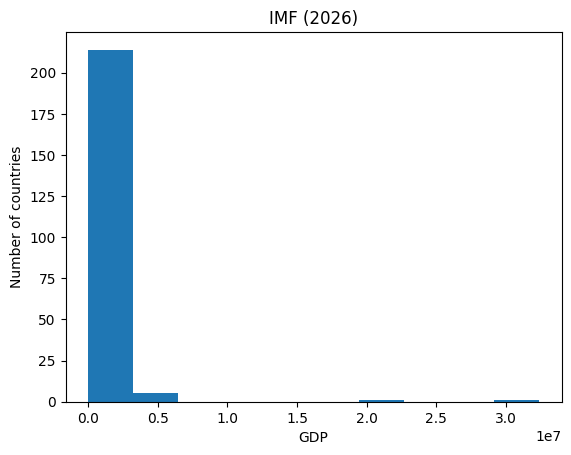

In [ ]:
#Build a histogram of IMF_Forecast

plt.hist(df['IMF (2026)'], bins=10)
plt.title('IMF (2026)')
plt.xlabel('GDP')
plt.ylabel('Number of countries')
plt.show()

Розподіл показників IMF (2026) є сильно скошеним вправо. Більшість країн мають відносно невеликі значення ВВП, тоді як невелика кількість країн має значно більші показники. Особливо виділяються США та Китай, значення яких суттєво перевищують показники більшості інших країн.


14.	Розрахуйте частку кожної країни в загальному значенні для кожного року (IMF (2026), World Bank (2025), United Nations (2024)).
 Як змінюються частки країн з часом (дати відповідь)?

In [ ]:
# calculate share of world GDP for each country for each year

df['IMF_Share'] = df['IMF (2026)'] / df['IMF (2026)'].sum()
df['WB_Share'] = df['World Bank (2025)'] / df ['World Bank (2025)'].sum()
df['UN_Share'] = df['United Nations (2024)'] / df['United Nations (2024)'].sum()

df.head(10)

,Country,IMF (2026),World Bank (2025),United Nations (2024),IMF_WB_Diff,std,IMF_Share,WB_Share,UN_Share
1,United States,32383920.0,30769700.0,29298000.0,1614220.0,1.329647e+07,0.238033,0.241690,0.243961
2,China[n 1],20851593.0,19498039.0,18743802.0,1353554.0,8.403818e+06,0.153267,0.153153,0.156078
3,Germany,5452858.0,5050923.0,4659929.0,401935.0,2.147879e+06,0.040080,0.039674,0.038803
4,Japan,4379253.0,4435163.0,4026211.0,55910.0,1.901140e+06,0.032189,0.034837,0.033526
5,United Kingdom,4264794.0,4002588.0,3685881.0,262206.0,1.707992e+06,0.031348,0.031440,0.030692
6,India,4153191.0,3956067.0,3952244.0,197124.0,1.735605e+06,0.030527,0.031074,0.032910
7,France,3596094.0,3366316.0,3160443.0,229778.0,1.442251e+06,0.026433,0.026442,0.026317
8,Italy,2738164.0,2551557.0,2380825.0,186607.0,1.089955e+06,0.020126,0.020042,0.019825
9,Russia,2656452.0,2561310.0,2173386.0,95142.0,1.083584e+06,0.019526,0.020119,0.018098
10,Brazil,2635912.0,2279920.0,2185822.0,355992.0,9.632445e+05,0.019375,0.017908,0.018201


15.	Візуалізуйте зміни в показниках для кожної країни за три роки на графіку. Які країни показують стабільне зростання або спад (дати відповідь)?

In [ ]:
# Find top 10 countries with the most significant change in share of world GDP between IMF and UN
df['IMF_UN_Diff'] = abs(df['IMF_Share'] - df['UN_Share'])
df_top10 = df.nlargest (10, 'IMF_UN_Diff')
df_top10

,Country,IMF (2026),World Bank (2025),United Nations (2024),IMF_WB_Diff,std,IMF_Share,WB_Share,UN_Share,IMF_UN_Diff
1,United States,32383920.0,30769700.0,29298000.0,1614220.0,1.329647e+07,0.238033,0.241690,0.243961,0.005928
2,China[n 1],20851593.0,19498039.0,18743802.0,1353554.0,8.403818e+06,0.153267,0.153153,0.156078,0.002811
6,India,4153191.0,3956067.0,3952244.0,197124.0,1.735605e+06,0.030527,0.031074,0.032910,0.002382
53,Iran,300293.0,362682.0,448092.0,62389.0,1.542954e+05,0.002207,0.002849,0.003731,0.001524
9,Russia,2656452.0,2561310.0,2173386.0,95142.0,1.083584e+06,0.019526,0.020119,0.018098,0.001428
15,South Korea,1931008.0,1872375.0,1875388.0,58633.0,8.275446e+05,0.014194,0.014707,0.015616,0.001423
4,Japan,4379253.0,4435163.0,4026211.0,55910.0,1.901140e+06,0.032189,0.034837,0.033526,0.001337
3,Germany,5452858.0,5050923.0,4659929.0,401935.0,2.147879e+06,0.040080,0.039674,0.038803,0.001278
10,Brazil,2635912.0,2279920.0,2185822.0,355992.0,9.632445e+05,0.019375,0.017908,0.018201,0.001174
16,Turkey,1640223.0,1597293.0,1323255.0,42930.0,6.751652e+05,0.012056,0.012546,0.011019,0.001038


In [ ]:
# Стабільне зростання: 2024 < 2025 < 2026
growth = df[
    (df['United Nations (2024)'] < df['World Bank (2025)']) &
    (df['World Bank (2025)'] < df['IMF (2026)'])
]

# Стабільний спад: 2024 > 2025 > 2026
decline = df[
    (df['United Nations (2024)'] > df['World Bank (2025)']) &
    (df['World Bank (2025)'] > df['IMF (2026)'])
]

print("Країни зі стабільним зростанням:")
print(growth['Country'].tolist())

print("\nКраїни зі стабільним спадом:")
print(decline['Country'].tolist())

Країни зі стабільним зростанням:
['United States', 'China[n 1]', 'Germany', 'United Kingdom', 'India', 'France', 'Italy', 'Russia', 'Brazil', 'Canada', 'Spain', 'Turkey', 'Indonesia', 'Netherlands', 'Saudi Arabia', 'Switzerland', 'Poland', 'Ireland', 'Belgium', 'Sweden', 'Israel', 'Argentina', 'Singapore', 'Austria', 'United Arab Emirates', 'Norway', 'Thailand', 'Colombia', 'Vietnam', 'Malaysia', 'Philippines', 'Bangladesh', 'Denmark', 'Romania', 'South Africa', 'Hong Kong[n 4]', 'Czech Republic', 'Egypt', 'Chile', 'Peru', 'Portugal', 'Nigeria', 'Kazakhstan', 'Finland', 'Algeria', 'Greece', 'New Zealand', 'Hungary', 'Ukraine[n 5]', 'Morocco', 'Uzbekistan', 'Slovakia', 'Angola', 'Bulgaria', 'Kenya', 'Ecuador', 'Dominican Republic', 'Guatemala', 'DR Congo', 'Ghana', 'Oman', 'Croatia', 'Ivory Coast', 'Serbia', 'Luxembourg', 'Costa Rica', 'Lithuania', 'Belarus', 'Uruguay', 'Panama', 'Tanzania[n 6]', 'Slovenia', 'Myanmar', 'Bolivia', 'Azerbaijan', 'Uganda', 'Cameroon', 'Jordan', 'Tunisia', 

**Висновок**

Під час лабораторної роботи я навчилася обробляти та аналізувати дані про ВВП країн за допомогою мови Python та бібліотеки Pandas. У процесі роботи я вносила зміни до таблиці: змінила назву стовпця `Country/Territory` на `Country`, видалила рядок `World`, замінила позначення `"—"` на `NaN` та перевірила дані на наявність пропущених значень і дублікатів.

Також я навчилася виконувати основні операції аналізу даних: обчислювати різницю між показниками IMF (2026) та World Bank (2025), визначати кореляцію між показниками IMF (2026), World Bank (2025) та United Nations (2024), знаходити стандартне відхилення, а також визначати країни з найвищими та найнижчими значеннями показників.

Для кращого аналізу даних я побудувала гістограму розподілу показників IMF (2026), розрахувала частку кожної країни в загальному значенні показників за кожен рік та візуалізувала зміни показників країн за три роки за допомогою графіка. На основі отриманих даних визначила країни, показники яких демонструють стабільне зростання або спад.

Отже, під час виконання лабораторної роботи я отримала практичні навички очищення, обробки, аналізу та візуалізації даних за допомогою Python і Pandas.
